In [264]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn SGD regression
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [265]:
# Import Populist Dataset
populist_df = pd.read_csv('../datasets/party/Populist.csv', delimiter=';')
print(populist_df.head())

                         party_name country_name  \
0        Bündnis Zukunft Österreich      Austria   
1  Freiheitliche Partei Österreichs      Austria   
2           Liste Hans-Peter Martin      Austria   
3                     Team Stronach      Austria   
4                JETZT - Liste Pilz      Austria   

                   party_name_english party_name_short  populist  \
0  Alliance for the Future of Austria              BZÖ         1   
1            Freedom Party of Austria              FPÖ         1   
2            Hans-Peter Martin's List           Martin         1   
3                       Team Stronach               TS         1   
4                     NOW – Pilz List             Pilz         1   

   populist_start  populist_end  populist_startnobl  populist_endnobl  \
0            1900          2100                1900              2100   
1            1900          2100                1900              2100   
2            1900          2100                1900        

In [266]:
# Only include needed columns
cleaned_populist_df = populist_df[["party_name_english", "country_name", 
                                   "populist", "populist_bl", "farright", 
                                   "farright_bl", "farleft", "farleft_bl", 
                                   "eurosceptic", "eurosceptic_bl", "in_parliament", 
                                   "parlgov_id"]]

# Filter for only EU countries
cleaned_populist_df = cleaned_populist_df[cleaned_populist_df['country_name'].isin([
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 
    'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden'])]
cleaned_populist_df.head()
# print(cleaned_populist_df.shape)

,party_name_english,country_name,populist,populist_bl,farright,farright_bl,farleft,farleft_bl,eurosceptic,eurosceptic_bl,in_parliament,parlgov_id
0,Alliance for the Future of Austria,Austria,1,0,0,0,0,0,1,0,0.0,1536.0
1,Freedom Party of Austria,Austria,1,0,1,0,0,0,1,0,1.0,50.0
2,Hans-Peter Martin's List,Austria,1,0,0,0,0,0,1,0,0.0,669.0
3,Team Stronach,Austria,1,0,0,0,0,0,1,0,0.0,2150.0
4,NOW – Pilz List,Austria,1,1,0,0,0,0,0,0,0.0,2651.0


In [267]:
# Import parlfacts party dataset
parlfacts_df = pd.read_csv('../datasets/party/Parlfacts_view_party.csv')
parlfacts_df.head()

,country_name_short,country_name,party_name_short,party_name_english,party_name,party_name_ascii,family_name_short,family_name,left_right,state_market,...,euprofiler,ees,castles_mair,huber_inglehart,ray,benoit_laver,chess,country_id,party_id,family_id
0,AUS,Australia,ACP-V,Australian Country Party (Vic),Australian Country Party (Vic),Australian Country Party (Vic),con,Conservative,7.4000,6.4000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33,1935,26
1,AUS,Australia,AD,Australian Democrats,Australian Democrats,Australian Democrats,soc,Social democracy,3.7004,3.3684,...,NaN,NaN,102.0,203.0,NaN,4703.0,NaN,33,120,11
2,AUS,Australia,AG,Australian Greens,Australian Greens,Australian Greens,eco,Green/Ecologist,1.5439,1.2982,...,NaN,NaN,NaN,NaN,NaN,4739.0,NaN,33,751,19
3,AUS,Australia,ALP,Australian Labor Party,Australian Labor Party,Australian Labor Party,soc,Social democracy,3.8833,4.0351,...,NaN,NaN,101.0,NaN,NaN,4721.0,NaN,33,1253,11
4,AUS,Australia,AP,Australia Party,Australia Party,Australia Party,lib,Liberal,6.0000,6.7000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33,1760,6


In [268]:
# Clean parlfacts dataset
cleaned_parlfacts_df = parlfacts_df[["country_name", "party_name_english", "family_name", 
                                     "left_right", "state_market", "liberty_authority", 
                                     "eu_anti_pro", "party_id"]]

# Only include EU countries
cleaned_parlfacts_df = cleaned_parlfacts_df[cleaned_parlfacts_df['country_name'].isin([
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 
    'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden'])]

cleaned_parlfacts_df = cleaned_parlfacts_df.drop(columns=['country_name', 'party_name_english'])
cleaned_parlfacts_df.head()

,family_name,left_right,state_market,liberty_authority,eu_anti_pro,party_id
48,Green/Ecologist,2.50,2.5,1.80,6.5,1739
49,Liberal,6.00,6.7,3.60,8.7,2688
50,Right-wing,8.83,6.0,8.83,2.5,1536
51,Christian democracy,6.20,5.7,7.10,8.3,1752
52,Liberal,6.00,6.7,3.60,8.7,2675


In [269]:
# Merge datasets on party ID
cleaned_populist_df['party_id'] = cleaned_populist_df['parlgov_id']
# cleaned_populist_df.head()

merged_df = pd.merge(cleaned_populist_df, cleaned_parlfacts_df, on=['party_id'], how='inner')
merged_df = merged_df.drop(columns=['parlgov_id'])
merged_df.head(30)

,party_name_english,country_name,populist,populist_bl,farright,farright_bl,farleft,farleft_bl,eurosceptic,eurosceptic_bl,in_parliament,party_id,family_name,left_right,state_market,liberty_authority,eu_anti_pro
0,Alliance for the Future of Austria,Austria,1,0,0,0,0,0,1,0,0.0,1536.0,Right-wing,8.8300,6.0000,8.8300,2.5000
1,Freedom Party of Austria,Austria,1,0,1,0,0,0,1,0,1.0,50.0,Right-wing,8.3494,6.3291,8.5149,1.9815
2,Hans-Peter Martin's List,Austria,1,0,0,0,0,0,1,0,0.0,669.0,Special issue,4.2000,5.0000,3.4000,2.8500
3,Team Stronach,Austria,1,0,0,0,0,0,1,0,0.0,2150.0,Liberal,6.0000,6.7000,3.6000,8.7000
4,NOW – Pilz List,Austria,1,1,0,0,0,0,0,0,0.0,2651.0,Green/Ecologist,2.5000,2.5000,1.8000,6.5000
5,National Front,Belgium,1,0,1,0,0,0,1,0,0.0,171.0,Right-wing,9.6550,8.0831,9.1382,1.5539
6,List Dedecker,Belgium,1,0,0,0,0,0,1,1,0.0,221.0,Liberal,6.0000,6.7000,3.6000,8.7000
7,People's Party,Belgium,1,0,1,0,0,0,1,0,0.0,438.0,Conservative,7.4000,6.4000,6.9000,7.9000
8,Workers' Party of Belgium,Belgium,0,0,0,0,1,0,1,0,1.0,256.0,Communist/Socialist,1.3000,1.4000,3.0000,3.3000
9,Flemish Interest,Belgium,1,0,1,0,0,0,1,0,1.0,993.0,Right-wing,9.6622,7.6950,9.5234,2.7560


In [270]:
# Clean NAN values
merged_df = merged_df.fillna(0)
print(merged_df.shape)

(191, 17)


# Integrity Sets

In [ ]:
# 2019 - 2024
integrity_df_1 = pd.read_csv('../datasets/mepmeetings.csv')
integrity_df_1 = integrity_df_1[["country", "group", "lobbyists", "mep"]]
integrity_df_1.head()

,country,group,lobbyists,mep
0,Malta,S&D,Terumo Europe,Alex AGIUS SALIBA
1,Malta,S&D,"Tilray, Frank Farnel",Alex AGIUS SALIBA
2,Malta,S&D,Cannabis for Cancer Declaration,Alex AGIUS SALIBA
3,Malta,S&D,Eurocotrol,Alex AGIUS SALIBA
4,Malta,S&D,"Facebook, Phillip Malloch, Facebook Director f...",Alex AGIUS SALIBA


In [287]:
# 2024 - 2029
integrity_df_2 = pd.read_json('../datasets/mepmeetings.json')
integrity_df_2 = integrity_df_2[["country", "group", "lobbyists", "mep"]]
integrity_df_2.head()

,country,group,lobbyists,mep
0,Finland,EPP,Konrad-Adenauer-Stiftung,Mika AALTOLA
1,Finland,EPP,International Institute for Democracy and Elec...,Mika AALTOLA
2,Finland,EPP,Elinkeinoelämän Keskusliitto,Mika AALTOLA
3,Finland,EPP,EPIS Thinktank,Mika AALTOLA
4,Finland,EPP,Konrad-Adenauer-Stiftung,Mika AALTOLA


In [289]:
integrity_df = integrity_df_1.merge(integrity_df_2)
integrity_df.head()

,country,group,lobbyists,mep
0,Malta,S&D,Terumo Europe,Alex AGIUS SALIBA
1,Malta,S&D,"Tilray, Frank Farnel",Alex AGIUS SALIBA
2,Malta,S&D,Cannabis for Cancer Declaration,Alex AGIUS SALIBA
3,Malta,S&D,Eurocotrol,Alex AGIUS SALIBA
4,Malta,S&D,"Facebook, Phillip Malloch, Facebook Director f...",Alex AGIUS SALIBA


In [291]:
# Make lobbyists an array
integrity_df['lobbyists'] = integrity_df['lobbyists'].apply(lambda x: np.array(list(map(str, x.split(',')))))
integrity_df.head()

,country,group,lobbyists,mep
0,Malta,S&D,[Terumo Europe],Alex AGIUS SALIBA
1,Malta,S&D,"[Tilray, Frank Farnel]",Alex AGIUS SALIBA
2,Malta,S&D,[Cannabis for Cancer Declaration],Alex AGIUS SALIBA
3,Malta,S&D,[Eurocotrol],Alex AGIUS SALIBA
4,Malta,S&D,"[Facebook, Phillip Malloch, Facebook Directo...",Alex AGIUS SALIBA


# Merge all sets

In [298]:
# Convert family-name to EP party

# Print unique values in family_name column
print(merged_df['family_name'].unique())

# Print uniquw groups in integrity_df
print(integrity_df['group'].unique())

party_mapping = {
    'Christian democracy' : 'EPP',
    'Agrarian' : 'EPP',
    'Social democracy' : 'S&D',
    'Green/Ecologist' : 'Greens / EFA',
    'Liberal' : 'RE',
    'Communist/Socialist' : 'GUE/NGL',
    'Conservative' : 'ECR',
    'Right-wing' : 'ECR',
    'Special issue' : 'No party',
    'no family' : 'No party',
    'to be coded' : 'No party'
}

merged_df['group'] = merged_df['family_name'].map(party_mapping)
merged_df.head()

<StringArray>
[         'Right-wing',       'Special issue',             'Liberal',
     'Green/Ecologist',        'Conservative', 'Communist/Socialist',
    'Social democracy', 'Christian democracy',            'Agrarian',
           'no family',         'to be coded']
Length: 11, dtype: str
<StringArray>
['S&D', 'RE', 'Greens / EFA', 'EPP', 'GUE/NGL', 'ECR']
Length: 6, dtype: str


,party_name_english,country_name,populist,populist_bl,farright,farright_bl,farleft,farleft_bl,eurosceptic,eurosceptic_bl,in_parliament,party_id,family_name,left_right,state_market,liberty_authority,eu_anti_pro,group
0,Alliance for the Future of Austria,Austria,1,0,0,0,0,0,1,0,0.0,1536.0,Right-wing,8.8300,6.0000,8.8300,2.5000,ECR
1,Freedom Party of Austria,Austria,1,0,1,0,0,0,1,0,1.0,50.0,Right-wing,8.3494,6.3291,8.5149,1.9815,ECR
2,Hans-Peter Martin's List,Austria,1,0,0,0,0,0,1,0,0.0,669.0,Special issue,4.2000,5.0000,3.4000,2.8500,No party
3,Team Stronach,Austria,1,0,0,0,0,0,1,0,0.0,2150.0,Liberal,6.0000,6.7000,3.6000,8.7000,RE
4,NOW – Pilz List,Austria,1,1,0,0,0,0,0,0,0.0,2651.0,Green/Ecologist,2.5000,2.5000,1.8000,6.5000,Greens / EFA


# TODO: Need to compile integrity data with rest properly

In [271]:
# Save cleaned set
merged_df.to_csv('../datasets/party/merged_party_data.csv', index=False)

In [272]:
training_df = merged_df.copy()

# Adding new features
training_df['eu_anti_pro_squared'] = training_df['eu_anti_pro'] ** 2
training_df['state_market_squared'] = training_df['state_market'] ** 2
training_df['liberty_authority_squared'] = training_df['liberty_authority'] ** 2

training_df.head()
print(training_df.columns)

Index(['party_name_english', 'country_name', 'populist', 'populist_bl',
       'farright', 'farright_bl', 'farleft', 'farleft_bl', 'eurosceptic',
       'eurosceptic_bl', 'in_parliament', 'party_id', 'family_name',
       'left_right', 'state_market', 'liberty_authority', 'eu_anti_pro',
       'eu_anti_pro_squared', 'state_market_squared',
       'liberty_authority_squared'],
      dtype='str')


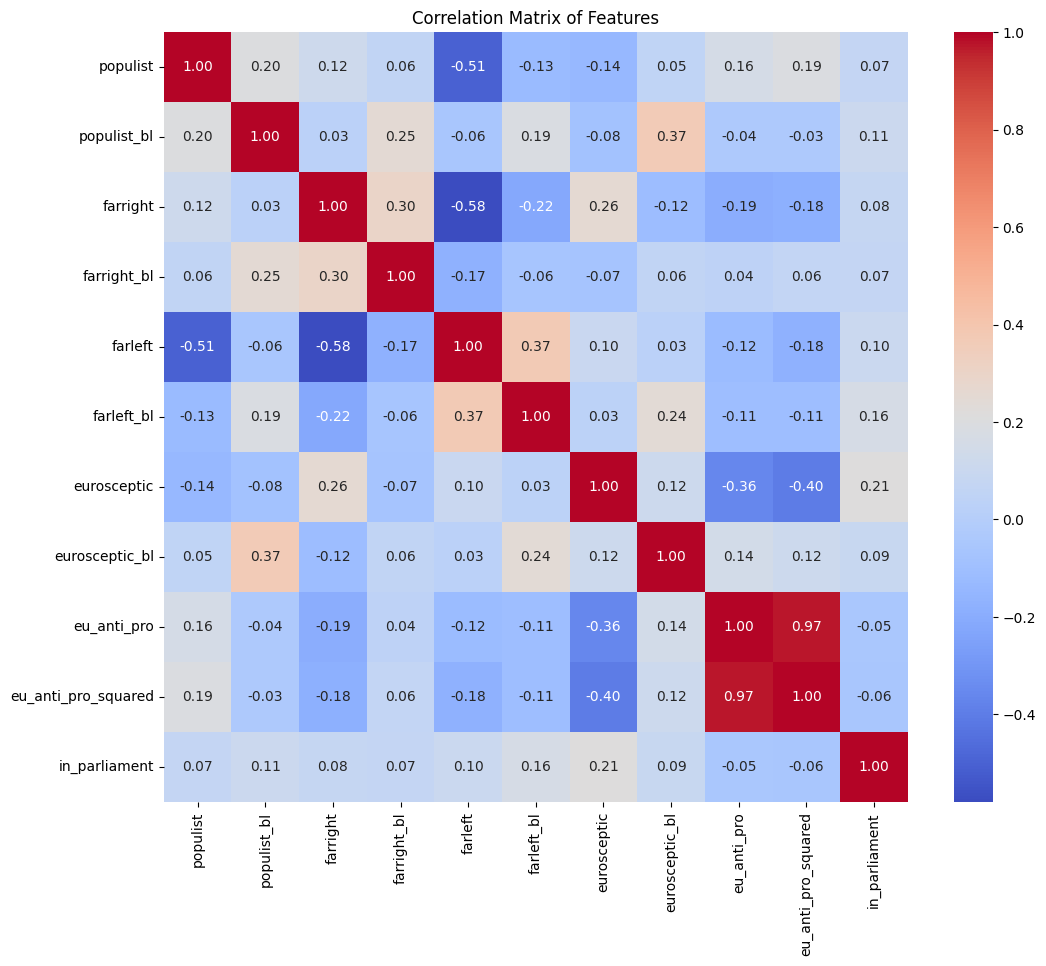

In [273]:
X = training_df[[
    'populist', 
    'populist_bl', 
    'farright', 
    'farright_bl',
    'farleft', 
    'farleft_bl', 
    'eurosceptic', 
    'eurosceptic_bl', 
    'country_name', 
    # 'family_name', 
    # 'left_right', 
    # 'state_market',
    # 'liberty_authority', 
    'eu_anti_pro',
    'eu_anti_pro_squared',
]]

y = training_df['in_parliament']

# Print correlation matrix for numeric X features
plt.figure(figsize=(12, 10))
sns.heatmap(X.select_dtypes(include=[np.number]).merge(y, left_index=True, right_index=True).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.savefig('correlation_matrix.png')
plt.show()

In [274]:
# Create dummies for categorical variables
columns_to_dummy = []
if 'country_name' in X.columns:
    columns_to_dummy.append('country_name')
if 'family_name' in X.columns:
    columns_to_dummy.append('family_name')

X = pd.get_dummies(X, columns=columns_to_dummy, drop_first=True)
print(X.columns)

# Check which rows have NAN values
nan_rows = np.isnan(X_train_scaled).any(axis=1)
print(f'Number of rows with NAN values: {nan_rows.sum()}')
print(X_train_scaled[nan_rows])

Index(['populist', 'populist_bl', 'farright', 'farright_bl', 'farleft',
       'farleft_bl', 'eurosceptic', 'eurosceptic_bl', 'eu_anti_pro',
       'eu_anti_pro_squared', 'country_name_Belgium', 'country_name_Bulgaria',
       'country_name_Croatia', 'country_name_Cyprus',
       'country_name_Czech Republic', 'country_name_Denmark',
       'country_name_Estonia', 'country_name_Finland', 'country_name_France',
       'country_name_Germany', 'country_name_Greece', 'country_name_Hungary',
       'country_name_Ireland', 'country_name_Italy', 'country_name_Latvia',
       'country_name_Lithuania', 'country_name_Luxembourg',
       'country_name_Netherlands', 'country_name_Poland',
       'country_name_Portugal', 'country_name_Romania',
       'country_name_Slovakia', 'country_name_Slovenia', 'country_name_Spain',
       'country_name_Sweden'],
      dtype='str')
Number of rows with NAN values: 0
[]


In [275]:
# LOO-CV training
y_pred_all = []

for i in range(len(X)):
    X_train = np.delete(X.values, i, axis=0)
    y_train = np.delete(y.values, i, axis=0)
    X_test = X.values[i].reshape(1, -1)
    y_test = y.values[i]
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = SGDClassifier(loss='log_loss',max_iter=1000, random_state=42, fit_intercept = False, alpha = .01, shuffle = False)
    model.fit(X_train_scaled, y_train)

    # Evaluate model
    y_pred = model.predict(X_test_scaled)

    y_pred_all.append(y_pred[0])


# Evaluate overall performance
accuracy = accuracy_score(y, y_pred_all)
print(f'LOO-CV Accuracy: {accuracy:.4f}')
print(classification_report(y, y_pred_all))
print(confusion_matrix(y, y_pred_all)) 

LOO-CV Accuracy: 0.6021
              precision    recall  f1-score   support

         0.0       0.66      0.65      0.66       112
         1.0       0.52      0.53      0.53        79

    accuracy                           0.60       191
   macro avg       0.59      0.59      0.59       191
weighted avg       0.60      0.60      0.60       191

[[73 39]
 [37 42]]


In [276]:
# Print out weights
print("Model Coefficients:")
print(model.intercept_)
print(model.coef_)
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

# Print scaling parameters
print("Feature Scaling Parameters:")
print("Means:", scaler.mean_)
print("Scales:", scaler.scale_)
    

Model Coefficients:
[0.]
[[ 0.52268639  0.34808475  0.55607576 -0.09115878  0.51822884  0.2524247
   0.20303947 -0.02656302  0.10029932  0.15799088  0.09514534 -0.19661843
   0.25902076 -0.27656207 -0.09857302  0.30693319  0.03523251  0.96849186
   0.18184106  0.02174315 -0.20296506  0.07450227  0.2169791  -0.03815167
  -0.15020005 -0.13357189  0.11737474  0.1915083   0.08830377  0.88745763
  -0.05370629 -0.03999207 -0.03462133  0.37677149  0.08201692]]
populist: 0.5227
populist_bl: 0.3481
farright: 0.5561
farright_bl: -0.0912
farleft: 0.5182
farleft_bl: 0.2524
eurosceptic: 0.2030
eurosceptic_bl: -0.0266
eu_anti_pro: 0.1003
eu_anti_pro_squared: 0.1580
country_name_Belgium: 0.0951
country_name_Bulgaria: -0.1966
country_name_Croatia: 0.2590
country_name_Cyprus: -0.2766
country_name_Czech Republic: -0.0986
country_name_Denmark: 0.3069
country_name_Estonia: 0.0352
country_name_Finland: 0.9685
country_name_France: 0.1818
country_name_Germany: 0.0217
country_name_Greece: -0.2030
country_name

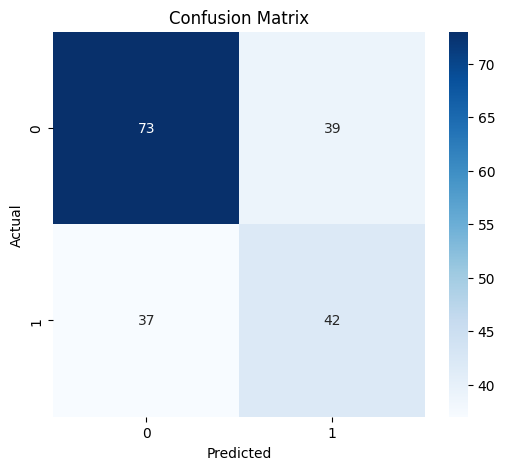

In [261]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y, y_pred_all), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('party_confusion_matrix.png')
plt.show()